In [1]:
!pip install -q kaggle
!pip install -q segmentation-models-pytorch
!pip install -q albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shiprachoubey","key":"979f6fc17d6ab5197dd0ca3646d265d1"}'}

In [33]:
!mkdir -p ~/.kaggle

In [4]:
!mv kaggle.json ~/.kaggle/

In [5]:
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!ls ~/.kaggle

kaggle.json


In [7]:
!kaggle datasets download -d orvile/bus-uclm-breast-ultrasound-dataset

Dataset URL: https://www.kaggle.com/datasets/orvile/bus-uclm-breast-ultrasound-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 97% 622M/642M [00:10<00:00, 62.4MB/s]
100% 642M/642M [00:10<00:00, 61.9MB/s]


In [ ]:
!unzip bus-uclm-breast-ultrasound-dataset.zip

In [9]:
import os
os.listdir('BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM')

['INFO.csv', 'masks', 'images']

In [10]:
import numpy as np
import pandas as pd
import os

In [11]:
import cv2
import matplotlib.pyplot as plt

image_dir = '/content/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/images'
mask_dir = '/content/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/masks'
if not os.path.exists(image_dir):
    raise FileNotFoundError(f"Image directory {image_dir} does not exist")
if not os.path.exists(mask_dir):
    raise FileNotFoundError(f"Mask directory {mask_dir} does not exist")


In [12]:
image_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]
mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]

print(f"Found {len(image_files)} image files in {image_dir}")
print(f"Found {len(mask_files)} mask files in {mask_dir}")

Found 683 image files in /content/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/images
Found 683 mask files in /content/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/masks


In [13]:
image_basenames = {os.path.splitext(f)[0].replace('frame_', ''): f for f in image_files}
mask_basenames = {os.path.splitext(f)[0].replace('mask_', ''): f for f in mask_files}

print("Sample image basenames:", list(image_basenames.keys())[:5])
print("Sample mask basenames:", list(mask_basenames.keys())[:5])


Sample image basenames: ['PAGY_000', 'STSP_027', 'ORPE_007', 'NIRO_016', 'COPE_000']
Sample mask basenames: ['PAGY_000', 'STSP_027', 'ORPE_007', 'NIRO_016', 'COPE_000']


In [14]:
common_keys = set(image_basenames.keys()) & set(mask_basenames.keys())

print(f"Found {len(common_keys)} matching image-mask pairs")

Found 683 matching image-mask pairs


In [15]:
data = []
for key in sorted(common_keys):
    image_path = os.path.join(image_dir, image_basenames[key])
    mask_path = os.path.join(mask_dir, mask_basenames[key])
    data.append({'image_path': image_path, 'mask_path': mask_path})

df = pd.DataFrame(data)

In [16]:
df.head()

,image_path,mask_path
0,/content/BUS-UCLM Breast ultrasound lesion seg...,/content/BUS-UCLM Breast ultrasound lesion seg...
1,/content/BUS-UCLM Breast ultrasound lesion seg...,/content/BUS-UCLM Breast ultrasound lesion seg...
2,/content/BUS-UCLM Breast ultrasound lesion seg...,/content/BUS-UCLM Breast ultrasound lesion seg...
3,/content/BUS-UCLM Breast ultrasound lesion seg...,/content/BUS-UCLM Breast ultrasound lesion seg...
4,/content/BUS-UCLM Breast ultrasound lesion seg...,/content/BUS-UCLM Breast ultrasound lesion seg...


In [17]:
df.columns

Index(['image_path', 'mask_path'], dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  683 non-null    object
 1   mask_path   683 non-null    object
dtypes: object(2)
memory usage: 10.8+ KB


In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
def display_image_mask_pairs(df, num_display=5):

    num_display = min(num_display, len(df))
    if num_display == 0:
        print("No image-mask pairs to display.")
        return

    display_df = df.head(num_display)

    fig, axes = plt.subplots(2, num_display, figsize=(5 * num_display, 6))
    if num_display == 1:
        axes = [[axes[0]], [axes[1]]]

    for i in range(num_display):
        image = cv2.imread(display_df['image_path'].iloc[i], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(display_df['mask_path'].iloc[i], cv2.IMREAD_GRAYSCALE)

        axes[0][i].imshow(image, cmap='gray')
        axes[0][i].set_title(f'Image {os.path.basename(display_df["image_path"].iloc[i])}')
        axes[0][i].axis('off')

        axes[1][i].imshow(mask, cmap='gray')
        axes[1][i].set_title(f'Mask {os.path.basename(display_df["mask_path"].iloc[i])}')
        axes[1][i].axis('off')

    plt.tight_layout()
    plt.show()


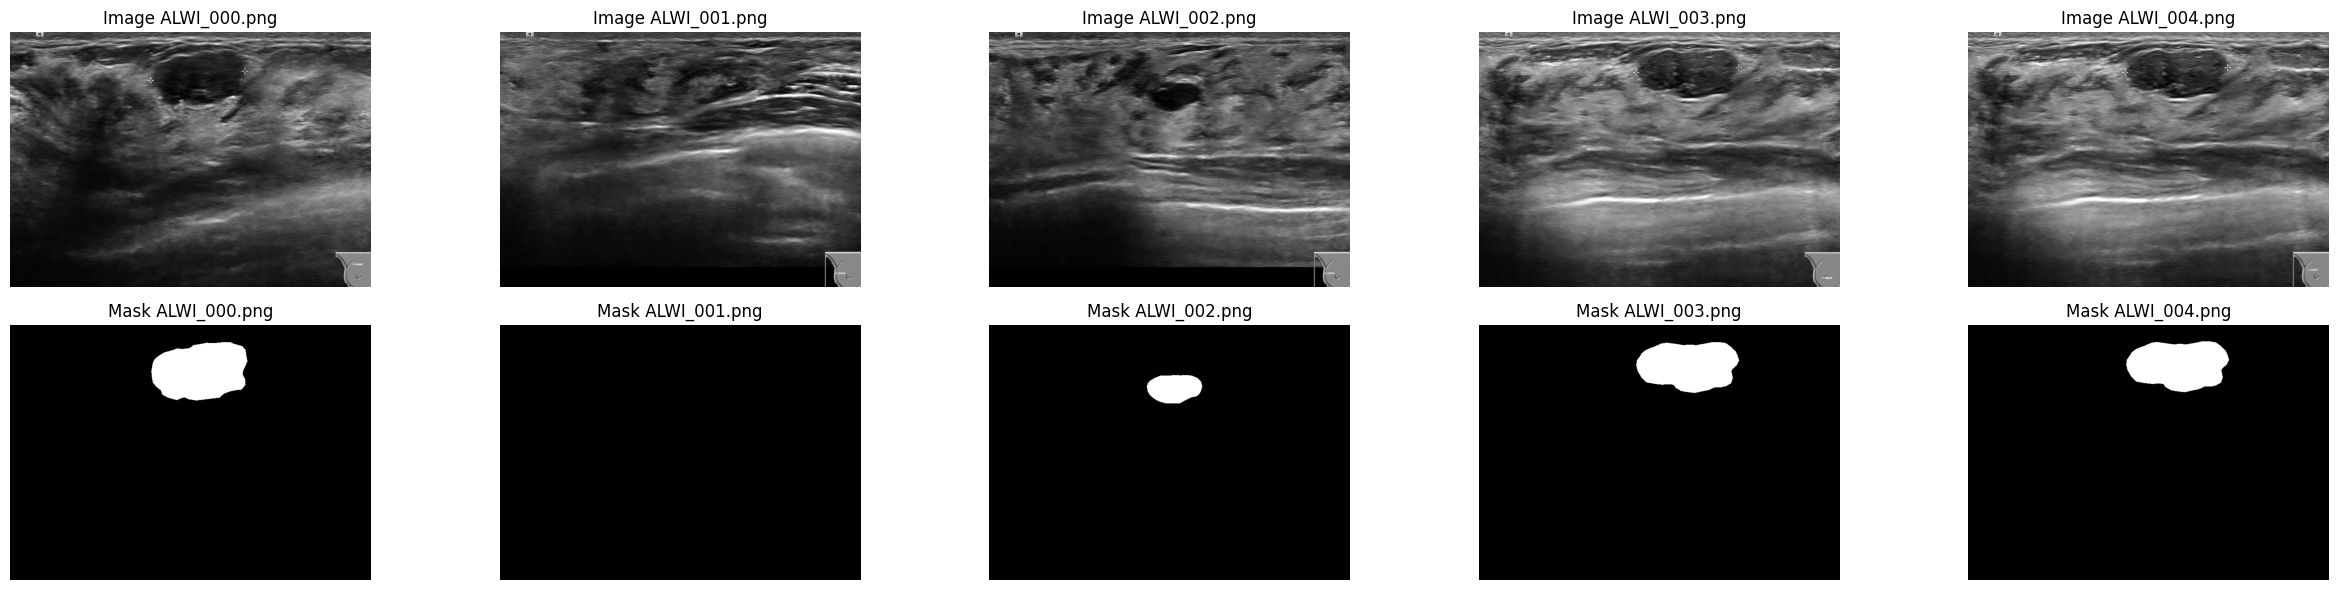

In [21]:
display_image_mask_pairs(df, num_display=5)

In [22]:
!pip install tensorflow

In [23]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [24]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

layers = tf.keras.layers
models = tf.keras.models

In [25]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def iou(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

In [26]:
def unet_plus_plus(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(c5)

    u4_1 = layers.Conv2DTranspose(512, 2, strides=(2, 2), padding='same')(c5)
    u4_1 = layers.concatenate([u4_1, c4])
    c4_1 = layers.Conv2D(512, 3, activation='relu', padding='same')(u4_1)
    c4_1 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4_1)
    u3_1 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(c4)
    u3_1 = layers.concatenate([u3_1, c3])
    c3_1 = layers.Conv2D(256, 3, activation='relu', padding='same')(u3_1)
    c3_1 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3_1)

    u3_2 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(c4_1)
    u3_2 = layers.concatenate([u3_2, c3, c3_1])
    c3_2 = layers.Conv2D(256, 3, activation='relu', padding='same')(u3_2)
    c3_2 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3_2)

    u2_1 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(c3)
    u2_1 = layers.concatenate([u2_1, c2])
    c2_1 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2_1)
    c2_1 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2_1)
    u2_2 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(c3_1)
    u2_2 = layers.concatenate([u2_2, c2, c2_1])
    c2_2 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2_2)
    c2_2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2_2)

    u2_3 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(c3_2)
    u2_3 = layers.concatenate([u2_3, c2, c2_1, c2_2])
    c2_3 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2_3)
    c2_3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2_3)

    u1_1 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c2)
    u1_1 = layers.concatenate([u1_1, c1])
    c1_1 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1_1)
    c1_1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1_1)

    u1_2 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c2_1)
    u1_2 = layers.concatenate([u1_2, c1, c1_1])
    c1_2 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1_2)
    c1_2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1_2)

    u1_3 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c2_2)
    u1_3 = layers.concatenate([u1_3, c1, c1_1, c1_2])
    c1_3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1_3)
    c1_3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1_3)
    u1_4 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c2_3)
    u1_4 = layers.concatenate([u1_4, c1, c1_1, c1_2, c1_3])
    c1_4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1_4)
    c1_4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1_4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c1_4)

    model = models.Model(inputs, outputs)
    return model
def load_and_preprocess_data(image_dir, mask_dir, img_size=(256, 256)):
      image_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]
      mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]
      print(f"Found {len(image_files)} image files in {image_dir}")
      print(f"Found {len(mask_files)} mask files in {mask_dir}")
      image_basenames = {os.path.splitext(f)[0].replace('frame_', ''): f for f in image_files}
      mask_basenames = {os.path.splitext(f)[0].replace('mask_', ''): f for f in mask_files}
      common_keys = set(image_basenames.keys()) & set(mask_basenames.keys())
      print(f"Found {len(common_keys)} matching image-mask pairs")

      images = []
      masks = []
      for key in sorted(common_keys):
        img_path = os.path.join(image_dir, image_basenames[key])
        mask_path = os.path.join(mask_dir, mask_basenames[key])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"Warning: Could not read image file: {img_path}. Skipping.")
            continue
        if mask is None:
            print(f"Warning: Could not read mask file: {mask_path}. Skipping.")
            continue

        img = cv2.resize(img, img_size)
        mask = cv2.resize(mask, img_size)
        img = img.astype(np.float32) / 255.0
        mask = (mask > 0).astype(np.float32)
        images.append(img)
        masks.append(mask)
      images = np.array(images)[..., np.newaxis]
      masks = np.array(masks)[..., np.newaxis]
      return images, masks
def plot_training_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax2.plot(history.history['dice_coefficient'], label='Train Dice')
    ax2.plot(history.history['val_dice_coefficient'], label='Val Dice')
    ax2.set_title('Dice Coefficient')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Dice')
    ax2.legend()

    ax3.plot(history.history['iou'], label='Train IoU')
    ax3.plot(history.history['val_iou'], label='Val IoU')
    ax3.set_title('IoU')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('IoU')
    ax3.legend()
    plt.tight_layout()
    plt.show()
def display_predictions(model, x_test, y_test, num_display=5):
    num_display = min(num_display, len(x_test))
    if num_display == 0:
        print("No test samples to display.")
        return

    preds = model.predict(x_test[:num_display])
    preds = (preds > 0.5).astype(np.float32)
    fig, axes = plt.subplots(3, num_display, figsize=(5 * num_display, 7))

    if num_display == 1:
        axes = [[axes[0]], [axes[1]], [axes[2]]]
    for i in range(num_display):
        axes[0][i].imshow(x_test[i, :, :, 0], cmap='gray')
        axes[0][i].set_title(f'Image {i+1}')
        axes[0][i].axis('off')
        axes[1][i].imshow(y_test[i, :, :, 0], cmap='gray')
        axes[1][i].set_title(f'Ground Truth {i+1}')
        axes[1][i].axis('off')
        axes[2][i].imshow(preds[i, :, :, 0], cmap='gray')
        axes[2][i].set_title(f'Prediction {i+1}')
        axes[2][i].axis('off')
    plt.tight_layout()
    plt.show()

# Define image and mask directories (copied from cell hhaXs0RncnQE to resolve NameError)
image_dir = '/content/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/images'
mask_dir = '/content/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/masks'

images, masks = load_and_preprocess_data(image_dir, mask_dir)

Found 683 image files in /content/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/images
Found 683 mask files in /content/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/masks
Found 683 matching image-mask pairs


In [27]:
x_train, x_temp, y_train, y_temp = train_test_split(images, masks, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [28]:
print(f"Train: {len(x_train)}, Validation: {len(x_val)}, Test: {len(x_test)}")

Train: 478, Validation: 102, Test: 103


In [29]:
model = unet_plus_plus()

In [30]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[dice_coefficient, iou])

In [31]:
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=20, batch_size=16, verbose=1)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 450s 10s/step - dice_coefficient: 0.0494 - iou: 0.0256 - loss: 0.3508 - val_dice_coefficient: 0.0735 - val_iou: 0.0383 - val_loss: 0.1546
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - dice_coefficient: 0.0467 - iou: 0.0240 - loss: 0.1253 - val_dice_coefficient: 0.0622 - val_iou: 0.0322 - val_loss: 0.1507
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - dice_coefficient: 0.0494 - iou: 0.0254 - loss: 0.1374 - val_dice_coefficient: 0.0547 - val_iou: 0.0282 - val_loss: 0.1525
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - dice_coefficient: 0.0478 - iou: 0.0246 - loss: 0.1234 - val_dice_coefficient: 0.0657 - val_iou: 0.0341 - val_loss: 0.1467
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - dice_coefficient: 0.0500 - iou: 0.0257 - loss: 0.1237 - val_dice_coefficient: 0.0548 - val_iou: 0.0282 - val_loss: 0.1530
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - dice_coefficient: 0.0430 - iou: 0.0221 - loss: 0.1203 - val_dice_coefficient

Test Loss: 0.1065
Test Dice Coefficient: 0.1186
Test IoU: 0.0631


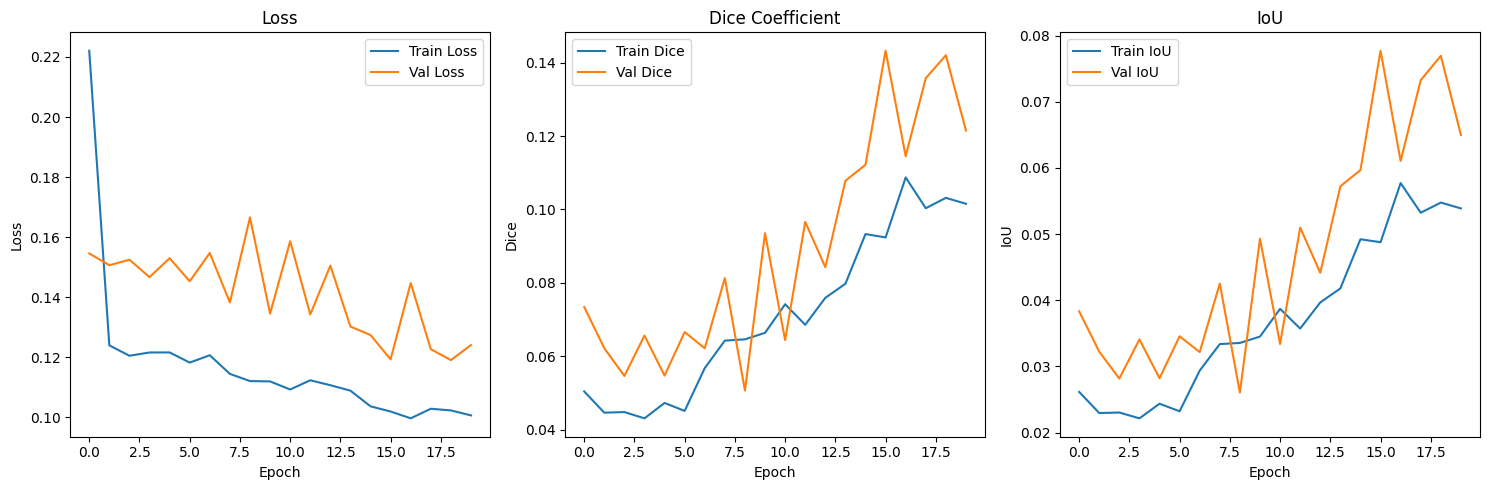

1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step


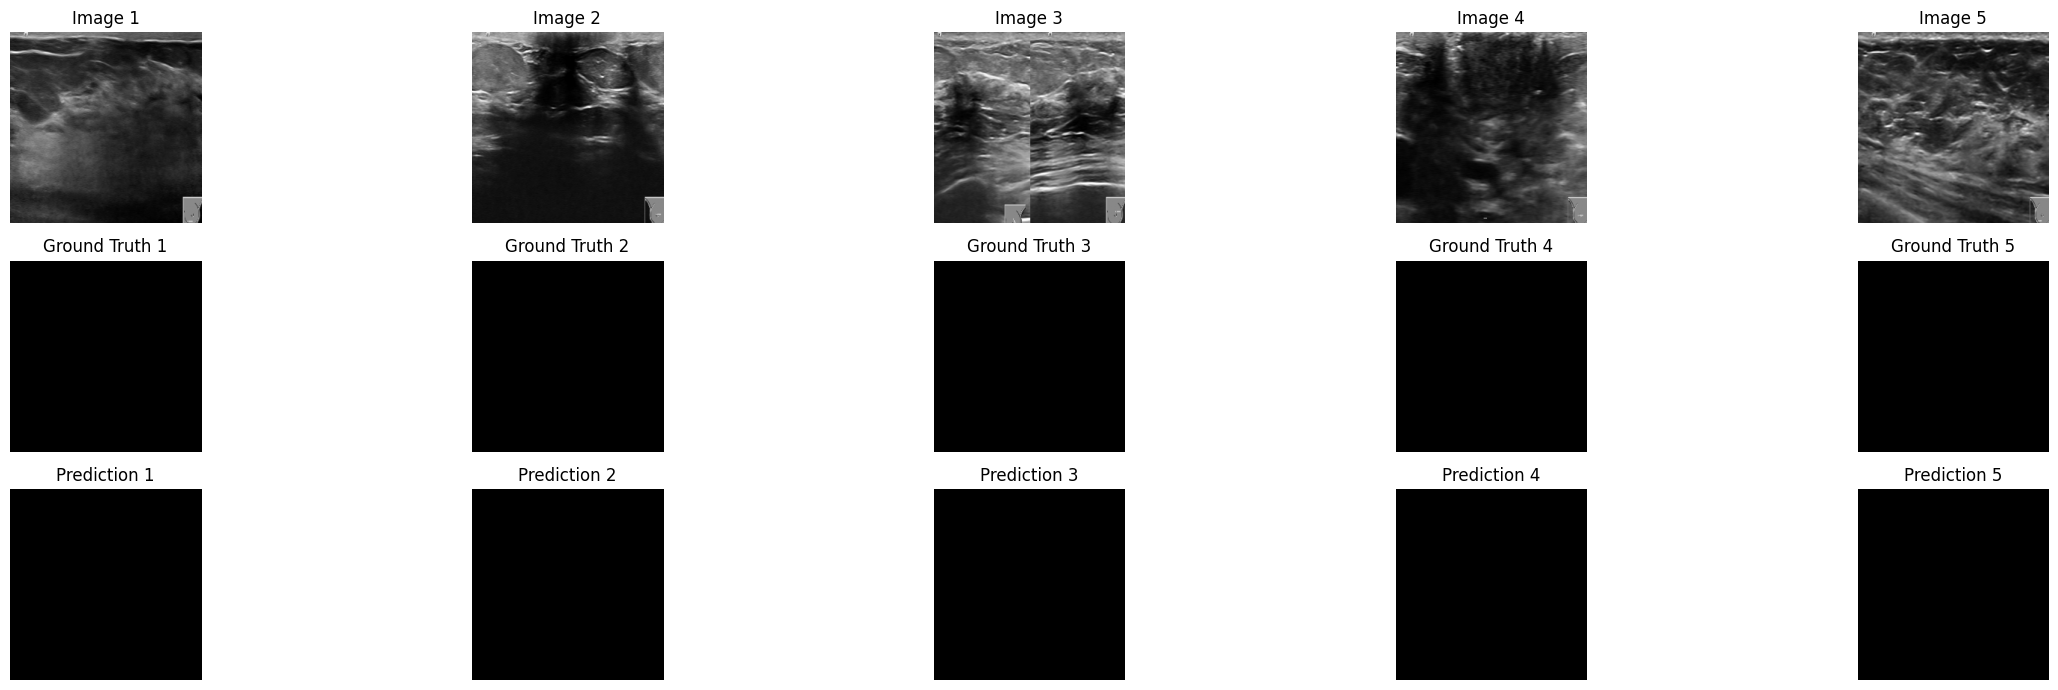

In [32]:
test_scores = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_scores[0]:.4f}")
print(f"Test Dice Coefficient: {test_scores[1]:.4f}")
print(f"Test IoU: {test_scores[2]:.4f}")

plot_training_history(history)

display_predictions(model, x_test, y_test, num_display=5)